# Customer Intelligence System

This project demonstrates customer intelligence concepts using a country-level socio-economic dataset. Machine learning techniques are applied to segment countries based on their characteristics and build predictive models for classifying these segments.

## 1. Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("Country-data.csv")
dictionary = pd.read_csv("data-dictionary.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
dictionary.head()

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...


The dataset consists of socio-economic and health-related information for different countries. Each row represents a country, and each column contains a specific indicator such as income, GDP per capita, life expectancy, child mortality, inflation, imports, and exports. These features help us understand the overall development of each country and identify countries with similar characteristics using clustering techniques.

## 3. Dataset Inspection

In [5]:
df.shape

(167, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [8]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [10]:
df.duplicated().sum()

np.int64(0)

### Key Observations
* This dataset contains 167 rows and 10 columns, where each row represents a country and each column represents a socio-economic or health-related feature.
* The country column is categorical, while the remaining columns are numerical (int64 and float64).
* There are no missing values or duplicate records in the dataset, so no additional cleaning is required at this stage.
* The numerical features have different value ranges. For example, income and gdpp have much larger values than features like health and inflation.
* Since clustering algorithms such as K-Means are distance-based, the features will need to be scaled before building the clustering models.

## 4. Data Preprocessing

As part of this assignment, the following preprocessing tasks will be carried out before applying the clustering algorithms:

- Removing leading and trailing whitespace from column names.
- Checking for duplicate records and removing them if present.
- Verifying that numerical features have the correct data types.
- Handling missing values in numerical columns using the median.

In [11]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

numerical_columns = df.select_dtypes(include=['number']).columns
df[numerical_columns] = df[numerical_columns].apply(pd.to_numeric)

df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [13]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [14]:
df.duplicated().sum()

np.int64(0)

## 5. Feature Scaling

Before applying clustering algorithms, feature scaling is required because:

- **K-Means is a distance-based algorithm**, so features with larger values can dominate the distance calculation.
- **Features have different value ranges**, which may lead to biased cluster formation.
- **StandardScaler** is used to standardize the numerical features so that each feature contributes equally during clustering.
- The scaled dataset will be used for applying **K-Means**, **DBSCAN**, and **PCA** in the following sections.

In [15]:
features = df.drop('country', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [16]:
scaled_df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04


### Key Observations

- All numerical features have been successfully standardized, with the mean approximately **0** and the standard deviation approximately **1**.
- The scaled dataset is now ready for clustering and dimensionality reduction techniques such as **K-Means**, **DBSCAN**, and **PCA**.

## 6. Finding the Optimal Number of Clusters (Elbow Method)

Before applying K-Means clustering, we need to determine an appropriate value of **K**, which represents the number of clusters.

The **Elbow Method** is used for this purpose because:

- It plots the **number of clusters (K)** on the x-axis and **WCSS (Inertia)** on the y-axis.
- As the number of clusters increases, the WCSS value decreases because the data points are grouped more closely around their centroids.
- After a certain point, increasing the number of clusters results in only a small reduction in WCSS.
- The point where the curve starts to flatten, forming an **"elbow"**, is considered the optimal value of **K**.

In [17]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

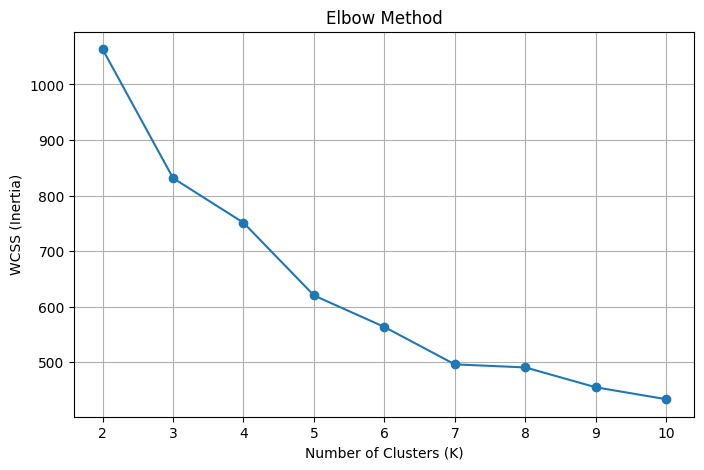

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

### Key Observations

- The WCSS decreases as the number of clusters increases, indicating more compact clusters.
- The elbow curve begins to flatten around **K = 5**, suggesting it as a reasonable choice based on the Elbow Method.
- Beyond this point, increasing the number of clusters results in only a small reduction in WCSS.
- For consistency with the assignment requirements, the K-Means model will be trained using **K = 3** as the baseline number of clusters.

## 7. K-Means Clustering

K-Means is an unsupervised, centroid-based clustering algorithm used to group similar data points into different clusters.

- It calculates the **Euclidean distance** between data points and the cluster centroids.
- Each data point is assigned to the cluster whose centroid is the closest.
- In this assignment, K-Means is used to segment countries into different groups based on their socio-economic and health-related features.
- This step assigns a cluster label to every country, which will be used for further analysis and visualization.

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_df)
df['Cluster'] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [20]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,86
1,36
2,45


### Key Observations

- A new **Cluster** column has been successfully added to the dataset, assigning each country to one of the three clusters.
- All **167 countries** have been grouped into **3 distinct clusters** using the K-Means algorithm.
- Cluster **0** contains **86** countries, Cluster **1** contains **36** countries, and Cluster **2** contains **45** countries.
- These cluster labels will be used in the upcoming sections for evaluating and visualizing the clustering results.

## 8. Silhouette Score

The Silhouette Score is used to evaluate the quality of the clusters formed by the clustering algorithm.

- It measures how similar a data point is to the other points in its own cluster and how different it is from points in the nearest neighboring cluster.
- A higher Silhouette Score indicates that the clusters are well separated and the data points are grouped appropriately.
- The score ranges from **-1 to 1**, where values closer to **1** represent better clustering performance.
- In this assignment, the Silhouette Score is used to evaluate the quality of the clusters generated by the K-Means algorithm.

In [21]:
silhouette = silhouette_score(scaled_df, clusters)
print(f"Silhouette Score: {silhouette:.3f}")

Silhouette Score: 0.286


### Key Observations

- The K-Means model achieved a **Silhouette Score of 0.286**.
- This indicates a **moderate clustering quality**, where the clusters show reasonable separation but also have some overlap.
- The score suggests that the countries have been grouped meaningfully, although the cluster boundaries are not highly distinct.

## 9. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that uses **eigenvalues** and **eigenvectors** to transform the data into a new set of orthogonal principal components.

- **PC1** captures the maximum variance present in the dataset, while **PC2** captures the second highest variance and is orthogonal to PC1.
- PCA is used to reduce the dimensionality of the dataset, making it easier to visualize and interpret high-dimensional data.
- PCA does **not** perform clustering; it only transforms the data while preserving as much information (variance) as possible.
- In this assignment, the dataset is reduced to **two principal components (PC1 and PC2)** to visualize the clusters formed by the K-Means algorithm.

In [22]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

In [23]:
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters
pca_df.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,2
1,0.429911,-0.588156,0
2,-0.285225,-0.455174,0
3,-2.932423,1.695555,2
4,1.033576,0.136659,0


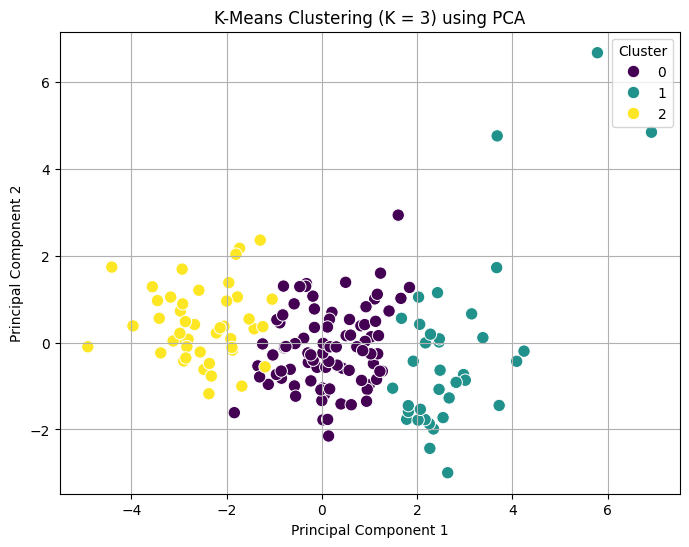

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('K-Means Clustering (K = 3) using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.show()

### Key Observations

- The PCA visualization shows that the countries have been grouped into **three clusters** by the K-Means algorithm.
- The clusters exhibit **moderate separation**, with some overlap between them, which is consistent with the obtained **Silhouette Score of 0.286**.
- A few data points appear to be isolated from the majority of the observations, suggesting the presence of **potential outliers** or countries with distinct socio-economic characteristics.
- The PCA plot provides a clear visual representation of the clustering results and helps evaluate the quality of the generated clusters..

## 10. Experimental Analysis: K-Means with K = 5

The Elbow Method suggested that a higher value of **K** could also be suitable for this dataset. Therefore, an additional experiment is performed using **K = 5** to compare the clustering quality with the baseline model (**K = 3**).

- The K-Means algorithm is trained again using **5 clusters**.
- The clustering quality is evaluated using the **Silhouette Score**.
- The resulting clusters are visualized using **PCA**.
- The results are compared with the baseline model to understand the effect of changing the number of clusters.

In [25]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
clusters_5 = kmeans_5.fit_predict(scaled_df)

In [26]:
silhouette_5 = silhouette_score(scaled_df, clusters_5)
print(f"Silhouette Score (K = 5): {silhouette_5:.3f}")

Silhouette Score (K = 5): 0.301


In [27]:
pca_df_5 = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df_5['Cluster'] = clusters_5
pca_df_5.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,2
1,0.429911,-0.588156,0
2,-0.285225,-0.455174,0
3,-2.932423,1.695555,2
4,1.033576,0.136659,0


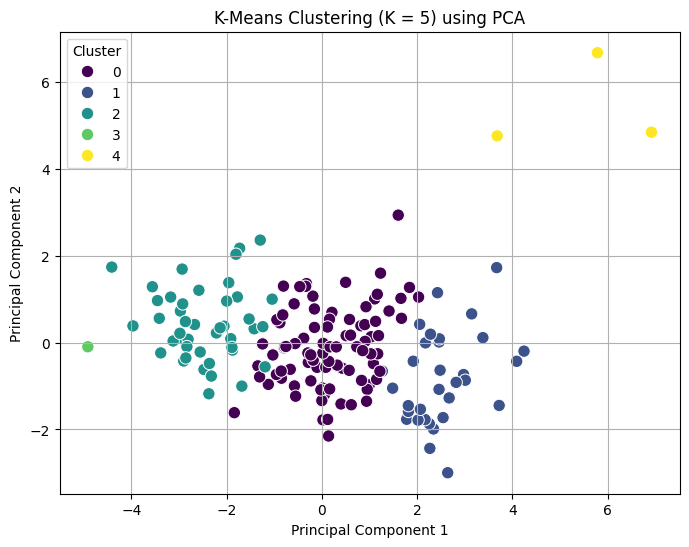

In [28]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df_5,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('K-Means Clustering (K = 5) using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.show()

### Key Observations

- Increasing the number of clusters from **3 to 5** resulted in a slight improvement in the clustering quality, with the **Silhouette Score increasing from 0.286 to 0.301**.
- The PCA visualization shows that some of the previously larger clusters have been divided into smaller and more compact groups.
- A few countries with distinct socio-economic characteristics form a separate cluster, indicating that increasing **K** captures finer patterns in the dataset.
- Although the clusters appear slightly better separated, some overlap is still present, suggesting only a moderate improvement over the baseline model.

## 11. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is an **unsupervised density-based clustering algorithm** that forms clusters based on the density of data points instead of using centroids.

- Unlike K-Means, DBSCAN does **not** require specifying the number of clusters beforehand.
- It uses two hyperparameters: **eps (ε)**, which defines the neighborhood radius, and **min_samples**, which specifies the minimum number of points required to form a dense region.
- DBSCAN classifies data points into three categories: **Core Points**, **Border Points**, and **Noise Points (Outliers)**.
- It is robust to outliers and can identify clusters of arbitrary shapes, making it more flexible than K-Means in many real-world scenarios.
- The performance of DBSCAN is highly dependent on the appropriate selection of **eps** and **min_samples**.

In [29]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(scaled_df)
df['DBSCAN_Cluster'] = dbscan_clusters
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


In [30]:
df['DBSCAN_Cluster'].value_counts().sort_index()

,count
DBSCAN_Cluster,
-1,30
0,137


### Key Observations

- DBSCAN identified **one dense cluster** containing **137 countries**.
- **30 countries** were classified as **noise points (-1)**, indicating that they do not belong to any dense region.
- Unlike K-Means, DBSCAN does not force every data point into a cluster and can naturally identify potential outliers.
- With the selected values of **eps = 1.5** and **min_samples = 5**, the dataset does not contain multiple dense regions.

In [31]:
pca_df_dbscan = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df_dbscan['Cluster'] = dbscan_clusters
pca_df_dbscan.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,0
1,0.429911,-0.588156,0
2,-0.285225,-0.455174,0
3,-2.932423,1.695555,-1
4,1.033576,0.136659,0


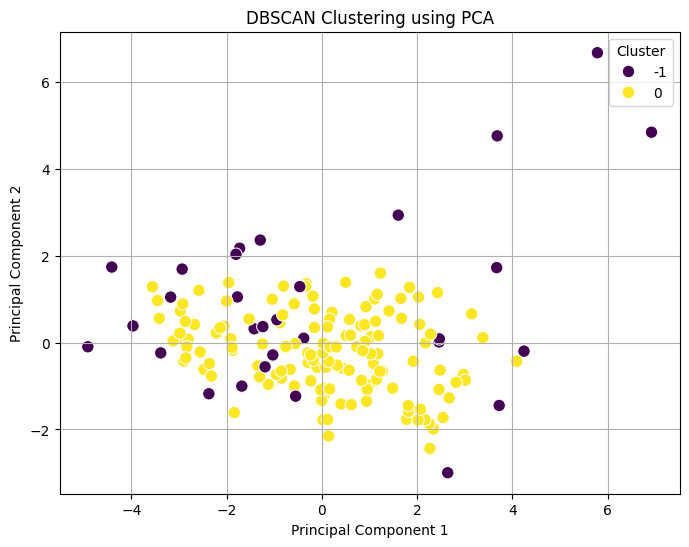

In [32]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df_dbscan,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('DBSCAN Clustering using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.show()

### Key Observations

- DBSCAN identified **one dense cluster** containing the majority of the countries, while **30 countries** were classified as **noise points (-1)**.
- The noise points are generally more isolated, indicating that they do not belong to any sufficiently dense region based on the selected **eps** and **min_samples** values.
- Unlike K-Means, DBSCAN does not force every data point into a cluster and can naturally identify potential outliers.
- The PCA visualization demonstrates that the dataset mainly consists of one dense group with several isolated observations rather than multiple dense clusters.

## 12. Comparative Analysis of Clustering Algorithms

The clustering algorithms applied in this assignment are compared based on their clustering behavior, cluster formation, outlier handling, and overall performance. This comparison highlights the strengths and limitations of each approach for the given dataset.

| Criteria | K-Means (K = 3) | K-Means (K = 5) | DBSCAN |
|----------|-----------------|-----------------|---------|
| Algorithm Type | Centroid-based | Centroid-based | Density-based |
| Number of Clusters | 3 | 5 | 1 |
| Noise / Outlier Detection | No | No | Yes (30 noise points) |
| Silhouette Score | 0.286 | 0.301 | Not Applicable |
| Cluster Separation | Moderate | Slightly Improved | One dense cluster with noise points |
| Best Suited For | General segmentation | Finer segmentation | Outlier detection and density-based clustering |

### Key Observations

- The **K-Means algorithm (K = 5)** achieved the highest Silhouette Score (**0.301**), indicating a slight improvement in cluster separation compared to the baseline model (**K = 3**, Silhouette Score = **0.286**).
- **DBSCAN** successfully identified **30 noise points** without requiring the number of clusters to be specified beforehand, demonstrating its ability to detect potential outliers.
- While **K-Means** is suitable for segmenting countries into well-defined groups, **DBSCAN** is more effective for identifying dense regions and isolated observations.
- The comparison shows that the choice of clustering algorithm depends on the objective of the analysis. **K-Means** is more appropriate for country segmentation, whereas **DBSCAN** is useful for outlier detection and density-based clustering.

## 13. Cluster Profiling

Cluster profiling helps interpret the clusters formed by the K-Means algorithm by comparing the average values of the socio-economic indicators for each cluster. This makes it easier to understand the characteristics of each group of countries and identify clusters representing developed, developing, or underdeveloped nations.

In [33]:
profile = df.groupby('Cluster')[features.columns].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71


In [34]:
profile.style.highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='lightcoral')

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.460000,40.270000,6.250000,47.360000,12321.740000,7.720000,72.570000,2.340000,6461.770000
1,5.000000,58.740000,8.810000,51.490000,45672.220000,2.670000,80.130000,1.750000,42494.440000
2,95.110000,28.600000,6.300000,42.310000,3539.840000,11.990000,59.060000,5.070000,1766.710000


## 14. Final Insights

- **Cluster 1** represents the most developed countries, with the highest average income, GDP per capita, life expectancy, health expenditure, and the lowest child mortality and fertility rates.
- **Cluster 2** represents the least developed countries, characterized by the lowest income and GDP per capita, highest child mortality and fertility rates, lowest life expectancy, and highest inflation.
- **Cluster 0** represents developing countries with moderate socio-economic and health indicators, positioned between the developed and underdeveloped groups.
- Based on the cluster profiles, countries belonging to **Cluster 2** should be prioritized for developmental aid and policy interventions, as they exhibit weaker economic and healthcare indicators compared to the other clusters.

## 15. Random Forest Classifier

Random Forest is a **supervised ensemble learning algorithm** that constructs multiple decision trees during training and combines their predictions to improve classification performance.

- Unlike clustering algorithms, Random Forest requires a **target variable** for training.
- In this assignment, the **cluster labels generated by the K-Means algorithm (K = 3)** are used as the target variable.
- The model learns the relationship between the socio-economic indicators and the generated country clusters.
- Random Forest is also useful for identifying the importance of different features in predicting the cluster labels.

### Libraries Required for Supervised Learning

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Preparing Features and Target Variable

In [36]:
X = df.drop(['country', 'Cluster', 'DBSCAN_Cluster'], axis=1)
y = df['Cluster']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (167, 9)
Target Vector Shape: (167,)


### Train-Test Split

Before training the Random Forest model, the dataset is divided into **training** and **testing** sets.

- The **training set (80%)** is used to train the model and learn the relationship between the input features and the target variable.
- The **testing set (20%)** is used to evaluate the model on unseen data.
- Splitting the data before training helps assess the model's ability to generalize and reduces the risk of overfitting.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (133, 9)
Testing Set: (34, 9)


### Model Training

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Predictions

In [39]:
y_pred_rf = rf_model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


In [40]:
prediction_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf
})

prediction_df.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,2,2
4,0,0
5,0,0
6,2,2
7,0,0
8,2,2
9,0,0


### Model Evaluation

The performance of the Random Forest classifier is evaluated using multiple classification metrics.

- **Accuracy** measures the overall proportion of correctly classified instances.
- **Precision** indicates how many of the predicted instances for a class are actually correct.
- **Recall** measures the model's ability to correctly identify all instances belonging to a class.
- **F1-Score** is the harmonic mean of Precision and Recall, providing a balanced measure of classification performance.
- The **Confusion Matrix** summarizes the model's predictions by comparing the actual and predicted class labels.

In [41]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")

Accuracy : 0.971
Precision: 0.974
Recall   : 0.971
F1-Score : 0.971


In [42]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [43]:
cm = confusion_matrix(y_test, y_pred_rf)
cm

array([[17,  0,  1],
       [ 0,  7,  0],
       [ 0,  0,  9]])

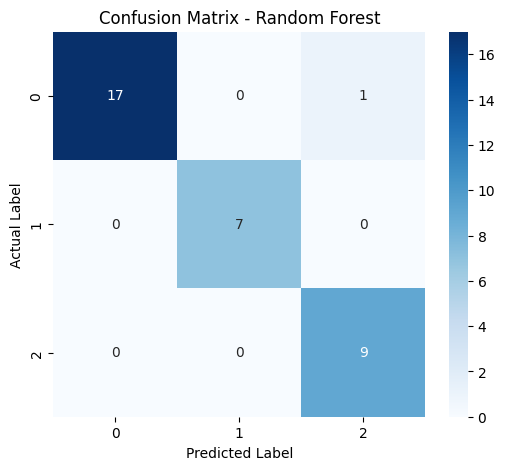

In [44]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()

### Key Observations

- The Random Forest classifier achieved an **accuracy of 97.1%**, indicating that it successfully learned the relationship between the socio-economic indicators and the K-Means cluster labels.
- The **Precision (97.4%)**, **Recall (97.1%)**, and **F1-Score (97.1%)** are all high and closely aligned, suggesting that the model performs consistently across the different clusters.
- The confusion matrix shows that **only one sample was misclassified**, while the remaining test samples were classified correctly, demonstrating strong predictive performance.
- The classification report indicates that **Cluster 1** was classified perfectly, while only a slight confusion was observed between **Clusters 0 and 2**.

## 16. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is a supervised ensemble learning algorithm that builds decision trees sequentially, where each new tree is trained to correct the errors made by the previous trees.

- Unlike Random Forest, which trains trees independently, XGBoost improves the model iteratively by minimizing prediction errors.
- It uses gradient boosting to achieve high predictive performance while reducing overfitting through regularization.
- In this assignment, XGBoost is trained using the same training and testing datasets to compare its performance with the Random Forest classifier.

### Model Training

In [45]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### Predictions

In [46]:
y_pred_xgb = xgb_model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


In [47]:
prediction_xgb = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_xgb
})

prediction_xgb.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,2,2
4,0,0
5,0,0
6,2,2
7,0,0
8,2,2
9,0,0


### Model Evaluation

In [48]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"Accuracy : {accuracy_xgb:.3f}")
print(f"Precision: {precision_xgb:.3f}")
print(f"Recall   : {recall_xgb:.3f}")
print(f"F1-Score : {f1_xgb:.3f}")

Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-Score : 1.000


In [49]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         9

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [50]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_xgb

array([[18,  0,  0],
       [ 0,  7,  0],
       [ 0,  0,  9]])

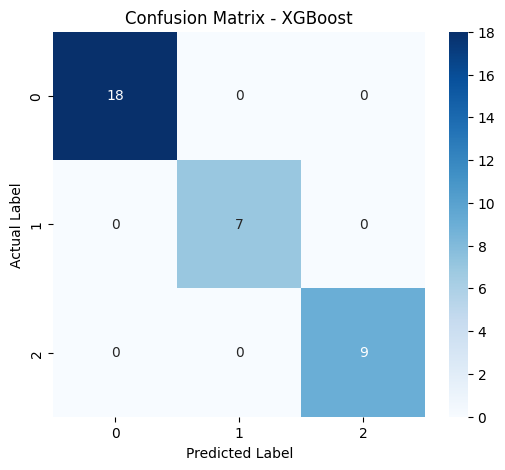

In [51]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=xgb_model.classes_,
    yticklabels=xgb_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost")

plt.show()

### Key Observations

- The XGBoost classifier achieved **100% accuracy**, correctly classifying all samples in the testing dataset.
- The **Precision**, **Recall**, and **F1-Score** of **1.00** indicate perfect classification performance across all three clusters.
- The confusion matrix shows that **every test sample was classified correctly**, with no misclassifications observed.
- Compared to the Random Forest classifier, XGBoost achieved a slight improvement in overall performance on this dataset.

## 17. Model Comparison

The performance of the Random Forest and XGBoost classifiers is compared using common classification metrics. This comparison helps identify the model that performs better in predicting the country clusters generated by the K-Means algorithm.

In [52]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_xgb],
    'Precision': [precision, precision_xgb],
    'Recall': [recall, recall_xgb],
    'F1-Score': [f1, f1_xgb]
})
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.970588,0.973529,0.970588,0.970942
1,XGBoost,1.000000,1.000000,1.000000,1.000000


### Key Observations

- Both **Random Forest** and **XGBoost** achieved excellent classification performance, indicating that the generated K-Means clusters are well separated.
- **XGBoost** outperformed **Random Forest**, achieving **100% accuracy**, precision, recall, and F1-score on the testing dataset.
- **Random Forest** achieved an accuracy of **97.1%**, with only one misclassified sample, demonstrating strong predictive performance.
- Based on the evaluation metrics, **XGBoost** is the better-performing classifier for predicting the generated country clusters in this dataset.

## 18. Feature Importance

Feature importance measures the contribution of each feature in predicting the cluster labels.

- Features with higher importance scores have a greater influence on the model's predictions.
- Analyzing feature importance helps identify the socio-economic indicators that play the most significant role in country segmentation.

In [53]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
8,gdpp,0.416883
0,child_mort,0.251738
4,income,0.233652
7,total_fer,0.033513
6,life_expec,0.030524
5,inflation,0.016553
2,health,0.008780
1,exports,0.004849
3,imports,0.003507


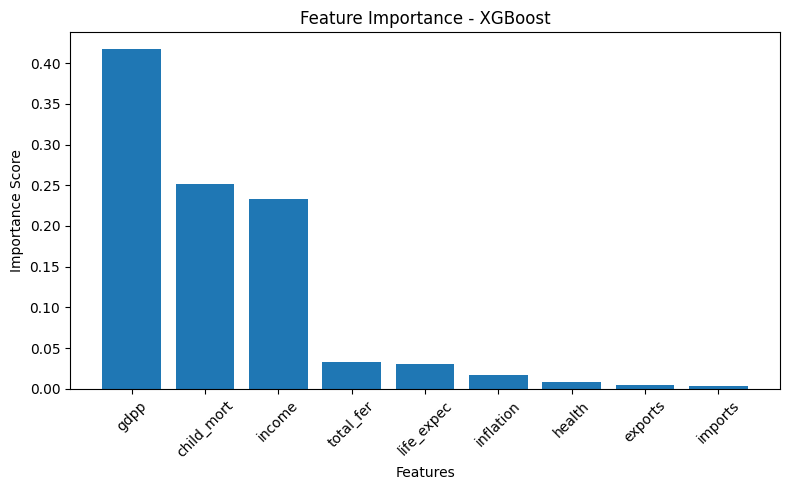

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

### Key Observations

- **GDP per capita (gdpp)** is the most influential feature for predicting the country clusters, indicating that economic prosperity is the strongest factor in country segmentation.
- **Child Mortality** and **Income** are the next most important features, suggesting that healthcare outcomes and economic conditions play a significant role in distinguishing countries.
- The top three features (**GDP per capita, Child Mortality, and Income**) contribute the majority of the model's predictive power.
- Features such as **Inflation, Health, Exports, and Imports** have relatively low importance, indicating a smaller contribution to the classification process.

## 19. Conclusion

This project successfully applied both **unsupervised** and **supervised** machine learning techniques to segment countries based on their socio-economic indicators.

- K-Means clustering effectively grouped countries with similar socio-economic characteristics, while PCA provided a clear two-dimensional visualization of the generated clusters.
- DBSCAN was also evaluated for comparison; however, it identified only a single dense cluster with several noise points, making K-Means more suitable for this dataset.
- Among the supervised learning models, **Random Forest** achieved an accuracy of **97.1%**, while **XGBoost** achieved **100% accuracy**, making it the best-performing classifier for predicting the generated clusters.
- Feature importance analysis revealed that **GDP per capita**, **Child Mortality**, and **Income** were the most influential factors in determining country clusters.

Overall, the project demonstrates how clustering techniques can be combined with classification models to analyze, interpret, and accurately predict country segments based on socio-economic data.